# Init

In [1]:
%cd .. 
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from model.lib.data import get_dataset
from model.utils import load_tuned_config, get_method, get_logger
import copy
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", message="The y_pred values do not sum to one")

/usr2/zihaoye/TabFT


/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Frequency Analysis

In [2]:
import numpy as np
from typing import Dict, Sequence, TypedDict
from sklearn.decomposition import PCA
from nfft import nfft_adjoint
from scipy.stats import linregress
import matplotlib.pyplot as plt

class Spectrum(TypedDict):
    """One principal-component spectrum."""
    k:        np.ndarray            # (nk,) positive spatial frequencies
    F:        np.ndarray            # (M, nk) complex NUDFT coeffs (M = #targets)
    power:    np.ndarray            # (nk,) mean |F|² across targets
    E:        np.ndarray            # (nk,) cumulative energy ∈ [0,1]
    hf_energy: float                # scalar: energy beyond ζ·Nyquist
    alpha:     float                # scalar: spectral-decay exponent


def adaptive_k_max(t: np.ndarray, q: float = 0.05) -> float:
    # pairwise 1-NN distance for each sample  (O(N²) memory OK for N≲3e4)
    dists = np.partition(np.abs(t[:, None] - t[None, :]), 1, axis=1)[:, 1]
    delta = max(np.quantile(dists, q), 1e-12)  # avoid Δ=0
    return np.pi / delta


def nudft_column(t: np.ndarray,
                 f: np.ndarray,
                 k_max: float,
                 nk: int) -> np.ndarray:
    x_scaled = -t                              # pynfft convention
    kgrid    = 2 * (nk + 1)                    # even → passes assertion
    F_full   = nfft_adjoint(x_scaled, f, kgrid)

    idx_dc   = nk + 1                          # 0-Hz bin
    F_pos    = F_full[idx_dc : idx_dc + nk + 1]
    return F_pos



def pc_line_spectrum(
    X: np.ndarray,
    y: np.ndarray,
    pcs: Sequence[int] | None = (0,),
    nk: int = 1_024,
    *,
    use_adaptive_kmax: bool = False,
    q_kmax: float = 0.05,
    zeta_hf: float = 0.4,
    frac_alpha: float = 0.10
) -> Dict[str, Spectrum]:

    X = np.asarray(X, float)
    y = np.asarray(y, complex)
    if y.ndim == 1:
        y = y[:, None]                # → (N,1)
    N, M = y.shape

    # 1. centre inputs and fit PCA
    Xc  = X - X.mean(axis=0, keepdims=True)
    pca = PCA(n_components=max(pcs) + 1, svd_solver="full").fit(Xc)

    spectra: Dict[str, Spectrum] = {}

    for idx in pcs:
        # 2. project on PC_i and z-score
        t = (Xc @ pca.components_[idx])
        t = (t - t.mean()) / t.std()

        # 3. choose Nyquist frequency
        k_max = adaptive_k_max(t, q=q_kmax) if use_adaptive_kmax else np.pi

        # safeguard: ensure t ∈ (-0.5,0.5] for the chosen k_max
        scale = max(1.0, (2.0 * np.abs(t).max()) + 1e-12)
        t_scaled = t / scale
        k_max /= scale

        k_vals = np.arange(1, nk + 1, dtype=float) * (k_max / nk)   # (nk,)

        # 4. NUDFT for every target dim
        Fcols = [
            nudft_column(t_scaled, y[:, m], k_max, nk)[1:] / N      # drop DC (k=0)
            for m in range(M)
        ]
        F = np.stack(Fcols, axis=0)            # (M, nk)

        # 5. mean power spectrum & cumulative energy
        power = np.mean(np.abs(F)**2, axis=0)  # (nk,)
        E = np.cumsum(power)
        E /= E[-1]

        # 6. HF energy beyond ζ·Nyquist
        idx_cut = int((1.0 - zeta_hf) * nk)        # start of HF band
        hf_energy = 1.0 - E[idx_cut]

        # 7. spectral-decay exponent α over top (1-frac) band
        idx0 = int(frac_alpha * nk)               # ignore low-k portion
        logk = np.log(k_vals[idx0:])
        logA = 0.5 * np.log(power[idx0:] + 1e-32)  # sqrt(power) ≈ |F|
        alpha = -linregress(logk, logA).slope

        spectra[f"pc{idx+1}"] = Spectrum(
            k=k_vals,
            F=F,
            power=power,
            E=E,
            hf_energy=float(hf_energy),
            alpha=float(alpha),
        )

    return spectra

def spectrum_plot(X: np.ndarray,
                       y: np.ndarray,
                       nk: int = 1024,
                       pc: int = 0,
                       **kw):
    """
    Quick matplotlib visual to check a single-PC spectrum.
    """
    spec = pc_line_spectrum(X, y, pcs=(pc,), nk=nk, **kw)[f"pc{pc+1}"]

    k, F, E = spec["k"], spec["F"][0], spec["E"]

    print(f"HF-energy (> {kw.get('zeta_hf', 0.4):.0%} Nyq)  = {spec['hf_energy']:.2%}")
    print(f"Spectral-decay exponent α  ≈ {spec['alpha']:.2f}\n")

    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(k, np.abs(F))
    plt.xlabel(r"$k$"); plt.ylabel(r"$|F(k)|$")
    plt.title("Magnitude spectrum")

    plt.subplot(1, 2, 2)
    plt.plot(k, E)
    plt.xlabel(r"$k$"); plt.ylabel(r"$E(k)$"); plt.ylim(0, 1)
    plt.title("Cumulative energy")
    plt.tight_layout(); plt.show()

## Conditional Expectation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

def _conditional_expectation(x: np.ndarray, y_bin: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y_bin[order]
    unique_x, idx = np.unique(x_sorted, return_inverse=True)

    sum_y  = np.bincount(idx, weights=y_sorted, minlength=unique_x.size)
    cnt_y  = np.bincount(idx, minlength=unique_x.size).astype(float)
    mu     = np.divide(sum_y, cnt_y, out=np.zeros_like(sum_y), where=cnt_y > 0)
    return unique_x, mu


def _compute_optimal_T(x: np.ndarray, y: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    delta_y = np.diff(y_sorted)
    TV = np.sum(np.abs(delta_y))
    return TV


def analyze_relative_slopes(
        X: np.ndarray,
        y: np.ndarray,
        is_regression: bool = False):
    n, d = X.shape
    class_list = np.unique(y) if not is_regression else [None]

    summary_records, all_relative_slopes = [], []
    feature_relative_slopes, cond_exp = {}, {}

    for j in range(d):
        x = X[:, j].astype(float)

        if np.allclose(x.max(), x.min()):
            summary_records.append((j, 0., 0., 0.))
            feature_relative_slopes[j] = np.array([])
            cond_exp[j] = []
            continue

        x = (x - x.min()) / (x.max() - x.min())

        feature_slopes, feature_curves = [], []

        for c in class_list:
            y_bin = (y == c).astype(float) if c is not None else y.astype(float)
            if is_regression and c is None and y_bin.ptp() > 0:
                y_bin = (y_bin - y_bin.min()) / y_bin.ptp()

            u, mu = _conditional_expectation(x, y_bin)
            if len(u) <= 1:
                feature_curves.append((c, u, mu))   # still store for completeness
                continue

            mu_c = mu - mu.mean()
            feature_curves.append((c, u, mu_c))

            T_opt = _compute_optimal_T(u, mu_c)
            if T_opt == 0:
                continue

            slopes = np.diff(mu_c) / np.diff(u)
            rel_slopes = np.abs(slopes) / T_opt
            feature_slopes.extend(rel_slopes)

        feature_slopes = np.asarray(feature_slopes)
        feature_relative_slopes[j] = feature_slopes
        all_relative_slopes.extend(feature_slopes)
        cond_exp[j] = feature_curves

        max_s, min_s, mean_s = (feature_slopes.max(),
                                feature_slopes.min(),
                                feature_slopes.mean()) if feature_slopes.size else (0., 0., 0.)
        summary_records.append((j, max_s, min_s, mean_s))

    summary_df = (pd.DataFrame(summary_records,
                               columns=['feature', 'max_relative_slope',
                                        'min_relative_slope', 'mean_relative_slope'])
                    .set_index('feature'))

    return dict(summary=summary_df,
                relative_slopes=feature_relative_slopes,
                all_relative_slopes=np.asarray(all_relative_slopes),
                cond_exp=cond_exp)


def plot_relative_slope_distribution(results: dict,
                                     feature_idx: int = None,
                                     bins: int = 50,
                                     figsize: tuple = (12, 4),
                                     class_label=None,
                                     show_conditional=True):
    import matplotlib.pyplot as plt


    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if slopes.size == 0:
            print(f"Feature {feature_idx} has no relative slopes to plot.")
            return

        nrows = 2 if show_conditional else 1
        fig, axes = plt.subplots(nrows, 1, figsize=figsize)
        if isinstance(axes, np.ndarray):
            axes = axes.ravel().tolist()
        else:
            axes = [axes]

        ax_hist = axes[0]
        ax_hist.hist(slopes, bins=bins, density=True, alpha=0.7,
                     edgecolor='black', linewidth=0.5)
        ax_hist.axvline(slopes.max(),  c='red',   ls='--', label=f'Max {slopes.max():.3f}')
        ax_hist.axvline(slopes.min(),  c='blue',  ls='--', label=f'Min {slopes.min():.3f}')
        ax_hist.axvline(slopes.mean(), c='green', ls='--', label=f'Mean {slopes.mean():.3f}')
        ax_hist.set_xlabel('Relative slope')
        ax_hist.set_ylabel('Density')
        ax_hist.set_title(f'Relative-slope distribution | feature {feature_idx}')
        ax_hist.grid(alpha=0.3)
        ax_hist.legend()

        if show_conditional:
            ax_curve = axes[1]
            curves = results['cond_exp'].get(feature_idx, [])
            to_plot = curves if class_label is None \
                           else [c for c in curves if c[0] == class_label]

            if not to_plot:
                ax_curve.set_title('No curve available')
            else:
                for c, u, mu_c in to_plot:
                    lbl = f'class {c}' if c is not None else 'regression'
                    ax_curve.plot(u, mu_c, lw=2, label=lbl)

            ax_curve.set_xlabel('u (feature value)')
            ax_curve.set_ylabel(r'$\mu_c(u)$  (mean-centred)')
            ax_curve.set_title('Conditional expectation')
            ax_curve.grid(alpha=0.3)
            ax_curve.legend()

        plt.tight_layout()
        return fig


    all_slopes = results['all_relative_slopes']
    if all_slopes.size == 0:
        print("No relative slopes to plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    ax1.hist(all_slopes, bins=bins, density=True, alpha=0.7,
             edgecolor='black', linewidth=0.5)
    ax1.axvline(all_slopes.max(), color='red',   ls='--', label=f'Max {all_slopes.max():.3f}')
    ax1.axvline(all_slopes.min(), color='blue',  ls='--', label=f'Min {all_slopes.min():.3f}')
    ax1.axvline(all_slopes.mean(),color='green', ls='--', label=f'Mean {all_slopes.mean():.3f}')
    ax1.set_xlabel('Relative slope')
    ax1.set_ylabel('Density')
    ax1.set_title('Overall relative-slope distribution')
    ax1.grid(alpha=0.3)
    ax1.legend()

    feature_data = [v for v in results['relative_slopes'].values() if v.size]
    labels = [f'F{j}' for j, v in results['relative_slopes'].items() if v.size]
    if feature_data:
        ax2.boxplot(feature_data, labels=labels, showfliers=False)
        ax2.set_xlabel('Feature')
        ax2.set_ylabel('Relative slope')
        ax2.set_title('Per-feature distribution')
        ax2.grid(alpha=0.3)
        plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    return fig



def get_relative_slope_stats(results: dict, feature_idx: int = None):
    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if len(slopes) == 0:
            return {'count': 0, 'mean': 0, 'std': 0, 'min': 0, 'max': 0}
        
        return {
            'count': len(slopes),
            'mean': slopes.mean(),
            'std': slopes.std(),
            'min': slopes.min(),
            'max': slopes.max(),
            'median': np.median(slopes),
            'q25': np.percentile(slopes, 25),
            'q75': np.percentile(slopes, 75)
        }
    else:
        stats_list = []
        for feature_idx, slopes in results['relative_slopes'].items():
            if len(slopes) == 0:
                stats_list.append([feature_idx, 0, 0, 0, 0, 0, 0, 0, 0])
            else:
                stats_list.append([
                    feature_idx,
                    len(slopes),
                    slopes.mean(),
                    slopes.std(),
                    slopes.min(),
                    slopes.max(),
                    np.median(slopes),
                    np.percentile(slopes, 25),
                    np.percentile(slopes, 75)
                ])
        
        return pd.DataFrame(stats_list, 
                           columns=['feature', 'count', 'mean', 'std', 'min', 'max', 'median', 'q25', 'q75'])

## Model outputs

In [4]:
import numpy as np, torch
from tqdm import tqdm

def collect_train_outputs(method):

    model = method.model.eval()
    N_total = len(method.y['train'])
    d_num   = 0 if method.N is None else method.N['train'].shape[1]

    x_num  = np.empty((N_total, d_num), dtype=np.float32) if d_num else None
    y_true = np.empty(N_total, dtype=np.float32)
    y_pred = None

    k = 0
    with torch.no_grad():
        for X, y in tqdm(method.train_loader, leave=False):
            if method.N is not None and method.C is not None:
                X_num, X_cat = X
            elif method.N is None:
                X_num, X_cat = None, X
            else:
                X_num, X_cat = X, None

            logits = model(X_num, X_cat)

            m = len(y)
            if d_num:
                x_num[k:k+m] = (
                    X_num.cpu().numpy() if X_num is not None else np.zeros((m,0))
                )
            y_true[k:k+m] = y.cpu().numpy().reshape(-1)

            if method.is_regression:
                preds = logits.cpu().numpy().reshape(-1)
            elif method.is_binclass:
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                preds = probs[:, 1]
            else:
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                preds = probs

            if y_pred is None:
                y_pred = np.empty((N_total, *preds.shape[1:]), dtype=preds.dtype)
            y_pred[k:k+m] = preds
            k += m

    assert k == N_total
    return x_num, y_true, y_pred

import numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

def quantile_bins(x, n_bins=20):
    kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    return kbd.fit_transform(x.reshape(-1,1)).astype(int).ravel(), kbd.bin_edges_[0]

def plot_feature_response(method, feature_idx: int,
                          n_bins: int = 20, class_id: int | None = None,
                          strategy: str = "quantile"):
    """
    strategy ∈ {'uniform', 'quantile'}
    """
    x_num, y_true, y_pred = collect_train_outputs(method)
    xj_raw = x_num[:, feature_idx].astype(float)
    xj = (xj_raw - xj_raw.min()) / (xj_raw.ptp() + 1e-12)   # [0,1]

    # --------- choose binning strategy ----------
    if strategy == "quantile":
        labels, edges = quantile_bins(xj, n_bins=n_bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
    else:  # uniform
        labels = np.digitize(xj, np.linspace(0, 1, n_bins+1)) - 1
        edges   = np.linspace(0, 1, n_bins+1)
        centers = (edges[:-1] + edges[1:]) / 2

    def group_mean(vals):
        s = np.bincount(labels, weights=vals, minlength=n_bins)
        c = np.bincount(labels, minlength=n_bins)
        out = s / np.maximum(c, 1)
        out[c == 0] = np.nan
        return out

    # empirical
    if method.is_regression:
        emp = group_mean(y_true)
        ylabel = "E[y | x_j]"
    else:
        tgt = (y_true == 1).astype(float) if method.is_binclass else (y_true == class_id)
        emp = group_mean(tgt)
        ylabel = f"Pr(y={1 if method.is_binclass else class_id} | x_j)"

    # model: optional grid for smoothness
    if strategy == "grid":
        ...
    else:
        if method.is_regression:
            mdl = group_mean(y_pred)
        else:
            mdl = group_mean(y_pred if method.is_binclass else y_pred[:,class_id])

    # -------------- plot -----------------
    plt.figure(figsize=(6,4))
    v = ~np.isnan(emp); plt.scatter(centers[v], emp[v], label="empirical")
    v = ~np.isnan(mdl); plt.plot(centers[v], mdl[v], label="model", lw=2)
    plt.xlabel(f"feature {feature_idx} (min-max)")
    plt.ylabel(ylabel); plt.legend(); plt.tight_layout(); plt.show()

## Transform Analysis

In [5]:
def transform_analysis(transform_list, N_data, C_data, y_data, is_regression=False):
    import numpy as np, matplotlib.pyplot as plt, math
    from transform.transform_pipeline import DataTransformPipeline
    from types import SimpleNamespace

    args = SimpleNamespace(seed=0)
    pipeline = DataTransformPipeline(transform_list, args, is_regression=is_regression)

    N_trans, C_trans, y_trans = pipeline.fit_transform(N_data=N_data.copy(), C_data=C_data, y_data=y_data)
    if "encoder" in pipeline.shared_state:
        N_train = torch.from_numpy(N_trans['train'].astype(np.float32)).to('cuda') if N_trans is not None else None
        C_train = torch.from_numpy(C_trans['train'].astype(np.float32)).to('cuda') if C_trans is not None else None
        encode_val = pipeline.shared_state['encoder'].encode(N_train, C_train)
        if N_trans is not None:
            N_trans['train'] = encode_val[0].detach().cpu().numpy().astype(np.float32)
        if C_trans is not None:
            C_trans['train'] = encode_val[1].detach().cpu().numpy().astype(np.float32)

    N_trans_train = N_trans['train']  # (n_samples, n_features)

    import math, numpy as np, matplotlib.pyplot as plt

    col_num = min(N_trans_train.shape[1], 30)
    cols    = min(max(col_num, 2), 5)
    rows    = math.ceil(col_num / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*2.5), squeeze=False)
    axes      = axes.reshape(rows, cols)

    for i in range(col_num):
        row, col = divmod(i, cols)
        axes[row, col].hist(N_trans_train[:, i], bins=100)
        axes[row, col].set_title(f'Column {i+1}')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')

    for j in range(col_num, rows*cols):
        axes.flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    
    if N_trans is not None:
        data = N_trans['train']
    else:
        data = C_trans['train']

    spectrum_plot(data, y_trans['train'])

    import pandas as pd

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    results = analyze_relative_slopes(data, y_trans['train'], is_regression=is_regression)
    print("Relative Slopes Analysis:")
    print(results['summary'])
    plot_relative_slope_distribution(results)
    stats = get_relative_slope_stats(results)
    print("Relative Slopes Statistics:")
    print(stats)

    return N_trans, C_trans, y_trans, results

# Env Var

In [6]:
from types import SimpleNamespace
model_type = 'mlp'
args = SimpleNamespace(seed=2025, model_type=model_type, config={}, device='cuda', batch_size=1024, use_float=True, max_epoch=200)


# Load dataset
# dataset_name = 'Contaminant-detection-in-packaged-cocoa-hazelnut-spread-jars-using-Microwaves-Sensing-and-Machine-Learning-11.0GHz(Urbinati)'
# dataset_name = 'E-CommereShippingData'
# dataset_name = 'estimation_of_obesity_levels'
# dataset_name = 'ASP-POTASSCO-classification'
# dataset_name = 'Ailerons'
# dataset_name = 'Bias_correction_r_2'
# dataset_name = 'electricity'
# dataset_name = 'Diamonds'
# dataset_name = 'Ailerons_DPGMM'
# dataset_name = 'IEEE80211aa-GATS'
# dataset_name = 'Intersectional-Bias-Assessment'
# dataset_name = 'Mobile_Price_Classification'
# dataset_name = 'Waterstress'
dataset_name = 'FOREX_audjpy-day-High'
# dataset_name = 'internet_firewall'
# dataset_name = 'BNG(tic-tac-toe)'
# dataset_name = 'Fitness_Club_c'
# dataset_name = 'FOREX_audjpy-day-High'

dataset_path = 'data'
train_val_data,test_data,info = get_dataset(dataset_name,dataset_path)
is_regression = (info['task_type'] == 'regression')
N_data = train_val_data[0] if train_val_data[0] else None
C_data = train_val_data[1] if train_val_data[1] else None
y_data = train_val_data[2] if train_val_data[2] else None 

# No transform

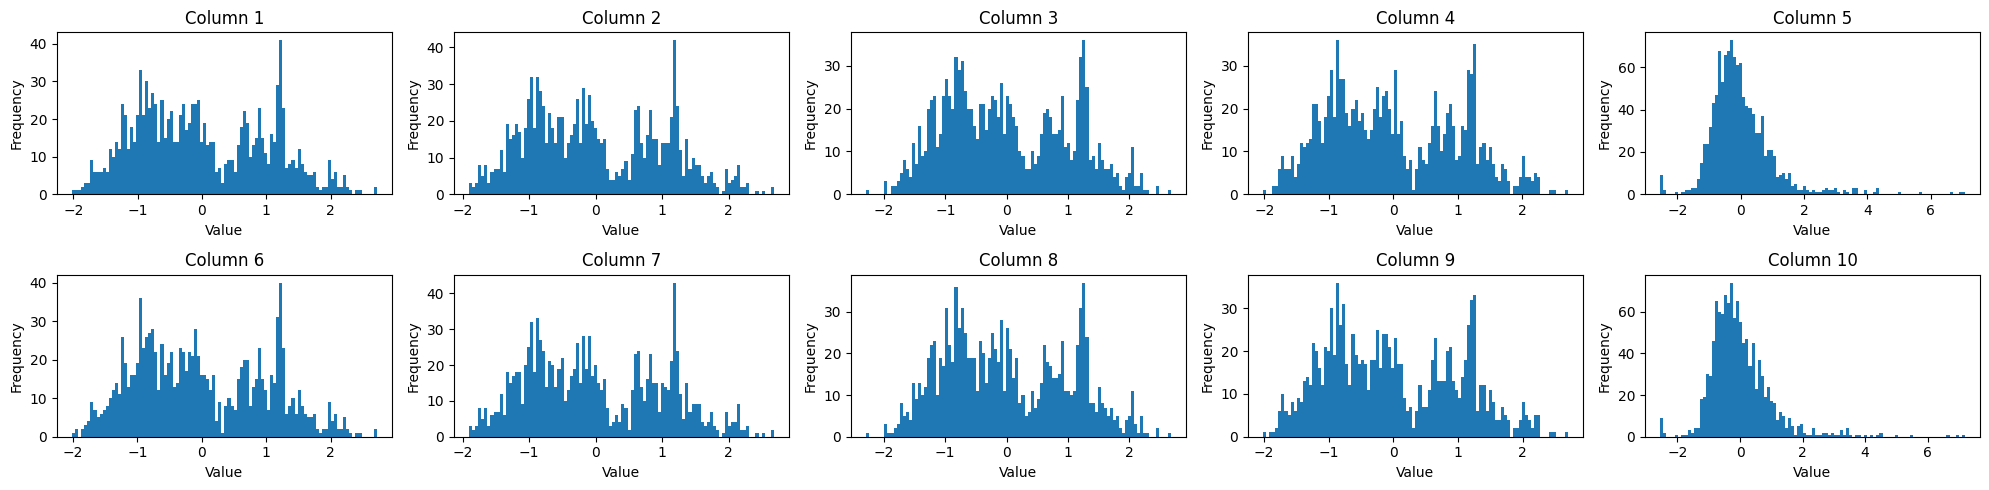

HF-energy (> 40% Nyq)  = 34.85%
Spectral-decay exponent α  ≈ 0.01



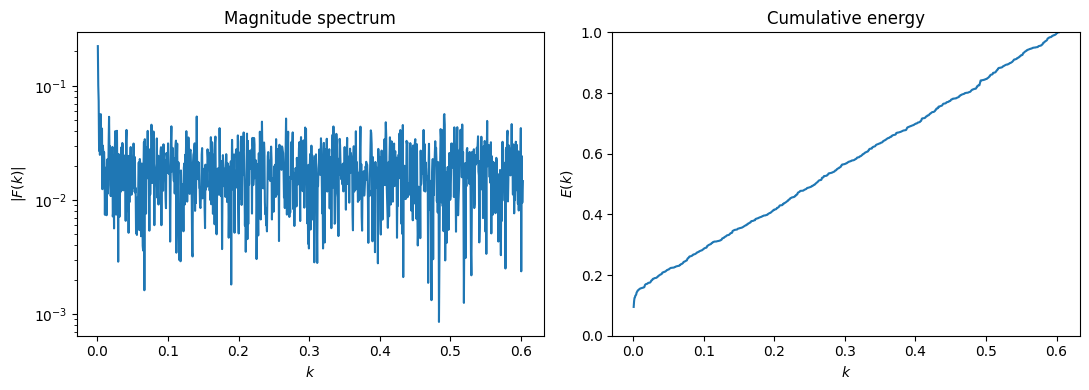

Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0                 55.155515                 0.0             4.908309
1                 50.906843                 0.0             4.129088
2                 58.097694                 0.0             4.865990
3                 53.762832                 0.0             4.372180
4              14819.755519                 0.0            44.211047
5                 57.180564                 0.0             4.501465
6                 50.503708                 0.0             3.979462
7                 58.043716                 0.0             4.583397
8                 52.598958                 0.0             4.569945
9               7628.404985                 0.0            33.958744
Relative Slopes Statistics:
   feature  count       mean         std  min           max    median  q25  \
0        0   2268   4.908309   11.074633

/tmp/ipykernel_4126094/477595629.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


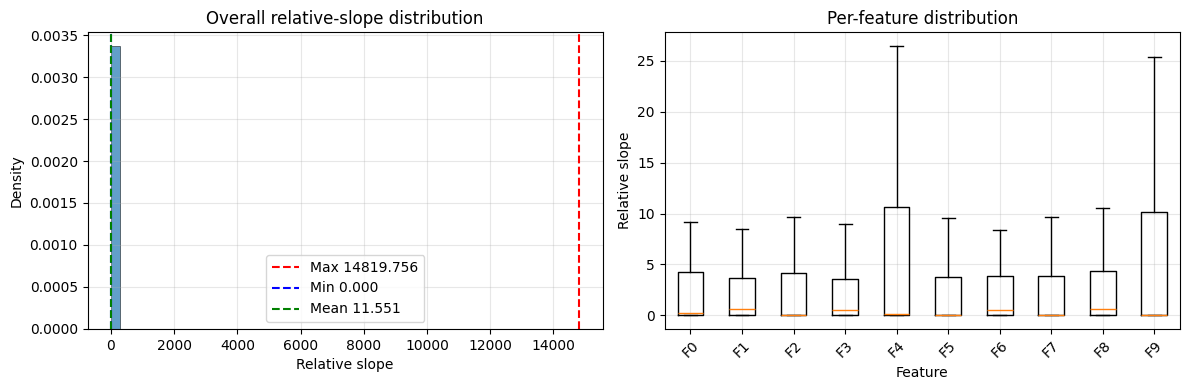

In [7]:
transform_list = [
    {
        'nan': {}
    },
    {
        'label': {}
    },
    {
        'cat_indice': {}
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]

N_data, C_data, y_data, ori_no_transform = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

# logger = get_logger('f_eval')
# args = copy.deepcopy(args)
# args.save_path = f'results_model/no_transform/{dataset_name}-mlp-Tune/Epoch200BZ1024'
# args.transform_list = transform_list
# args, is_loaded = load_tuned_config(args, logger=logger)
# print(f"Loaded config status: {is_loaded}")

# method_no_transform = get_method(args.model_type)(args, is_regression)
# method_no_transform.pre_transformed = True
# train_val_data = (copy.deepcopy(N_data), copy.deepcopy(C_data), copy.deepcopy(y_data))
# time_cost = method_no_transform.fit(train_val_data, info)

# PLE Uni Transform

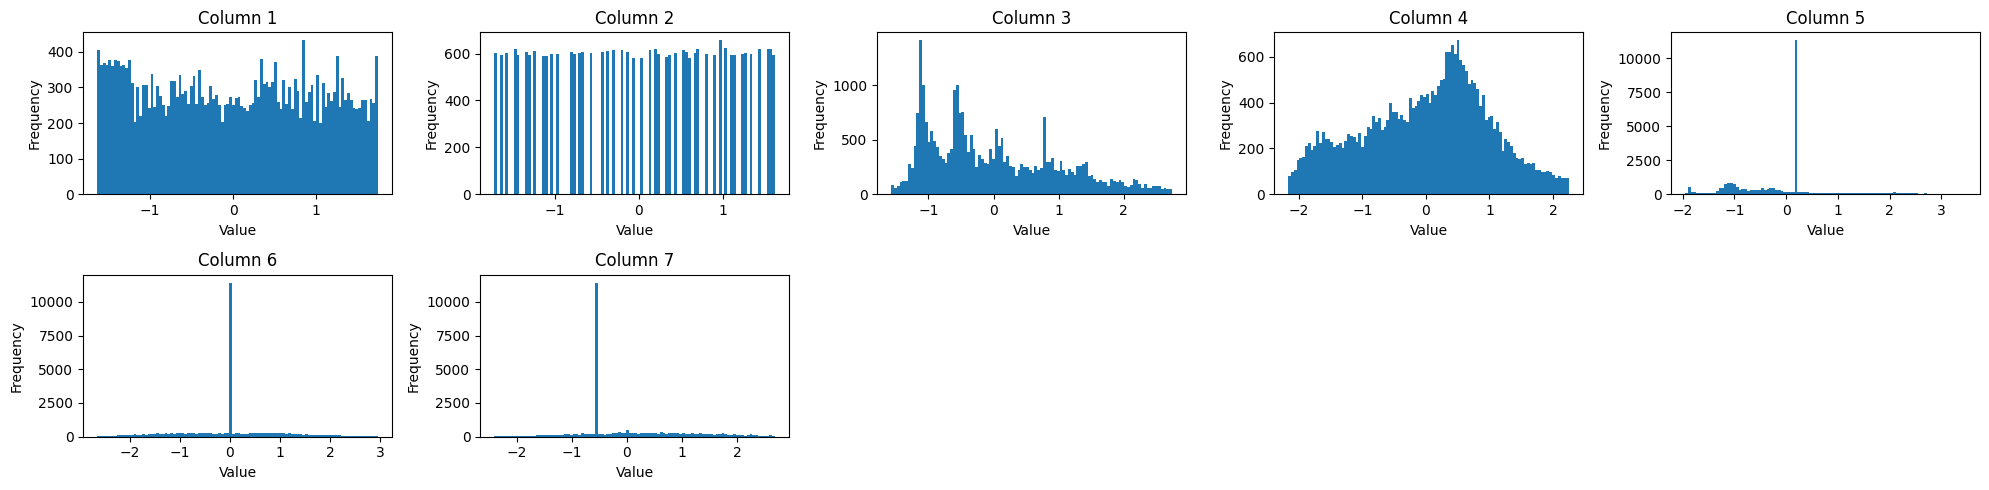

HF-energy (> 40% Nyq)  = 4.63%
Spectral-decay exponent α  ≈ -0.01



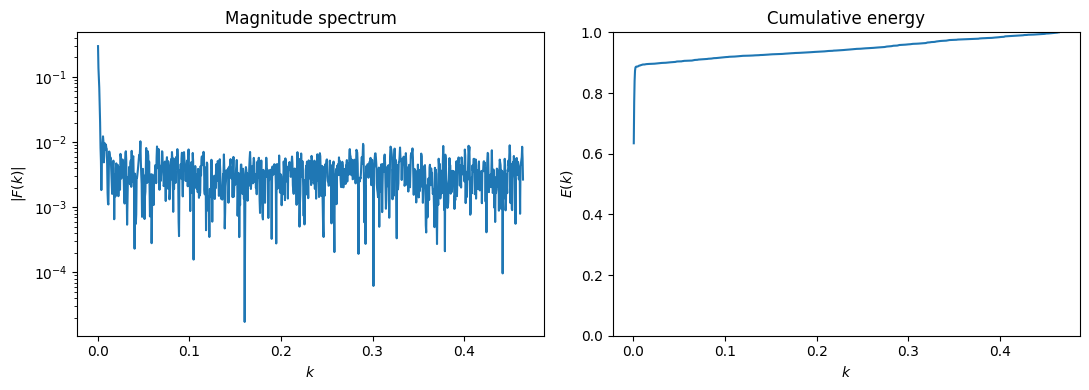

/tmp/ipykernel_3232083/477595629.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)
2025-07-20 20:58:49,664 - f_eval - INFO - Successfully merged tuned config into args.config


Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0                  4.828943            0.000000             1.125005
1                  5.742262            0.033104             1.161826
2                  7.455838            0.000000             1.081873
3                  5.840287            0.000000             1.121710
4                  6.158895            0.000000             1.092288
5                  5.877479            0.000000             1.117020
6                  5.641823            0.000000             1.148707
Relative Slopes Statistics:
   feature  count      mean       std       min       max    median       q25  \
0        0   1864  1.125005  0.932275  0.000000  4.828943  0.884336  0.378997   
1        1     94  1.161826  1.255283  0.033104  5.742262  0.710553  0.257702   
2        2   7280  1.081873  1.580868  0.000000  7.455838  0.414055  0.000000   
3

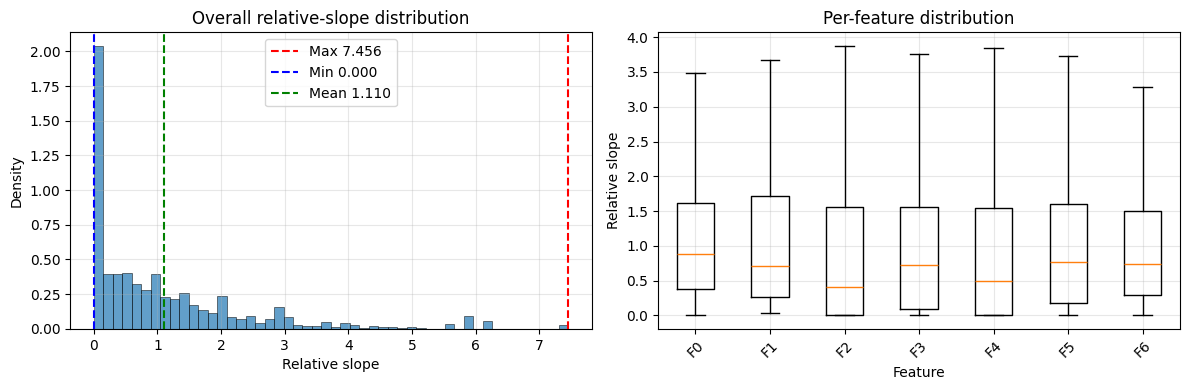

In [ ]:
transform_list = [
    {
        'uniple':
            {
                'n_bins': 1000000
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]


N_trans, C_trans, y_trans, trans_results_cdf = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

logger = get_logger('f_eval')
args = copy.deepcopy(args)
args.save_path = f'results_model/cdf/{dataset_name}-mlp-Tune/Epoch200BZ1024'
args.transform_list = transform_list
args, is_loaded = load_tuned_config(args, logger=logger)
print(f"Loaded config status: {is_loaded}")

method_cdf = get_method(args.model_type)(args, is_regression)
method_cdf.pre_transformed = True
train_val_data = (copy.deepcopy(N_trans), copy.deepcopy(C_trans), copy.deepcopy(y_trans))
time_cost = method_cdf.fit(train_val_data, info)

# Stretch Opt 

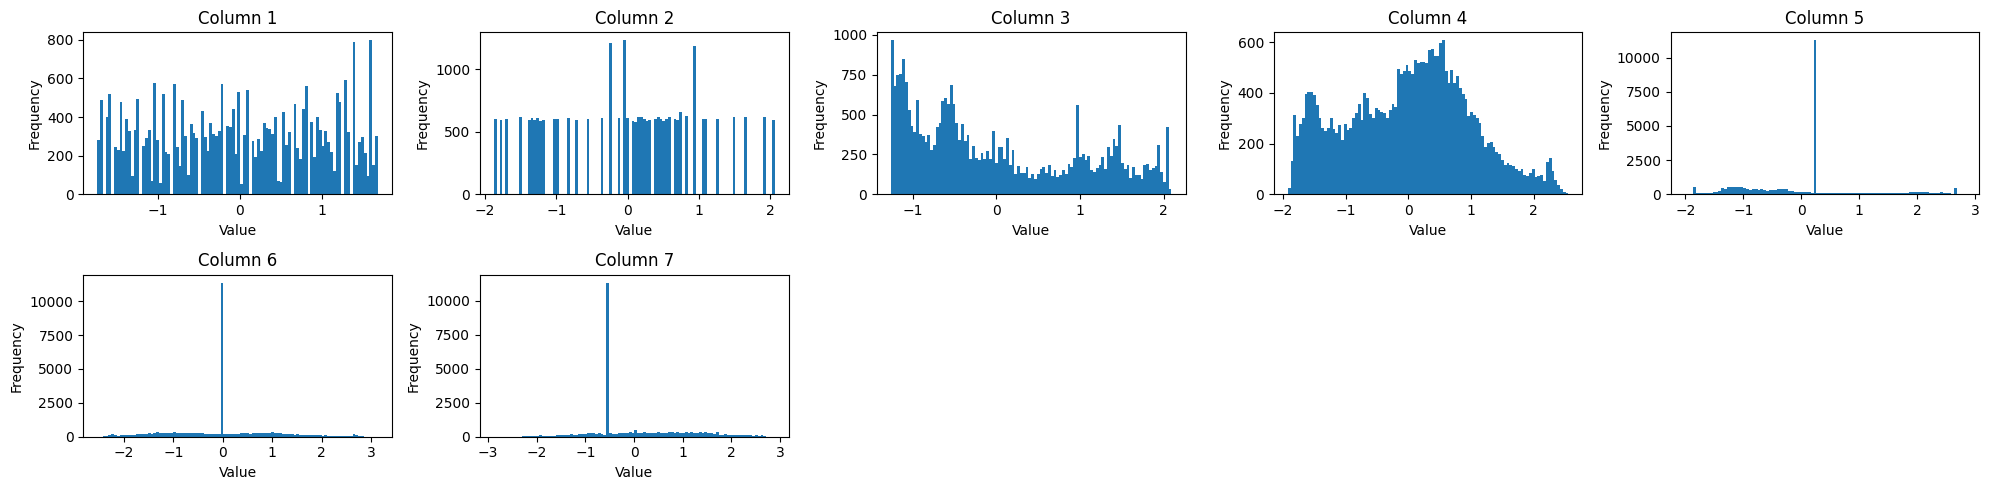

HF-energy (> 40% Nyq)  = 4.56%
Spectral-decay exponent α  ≈ 0.04



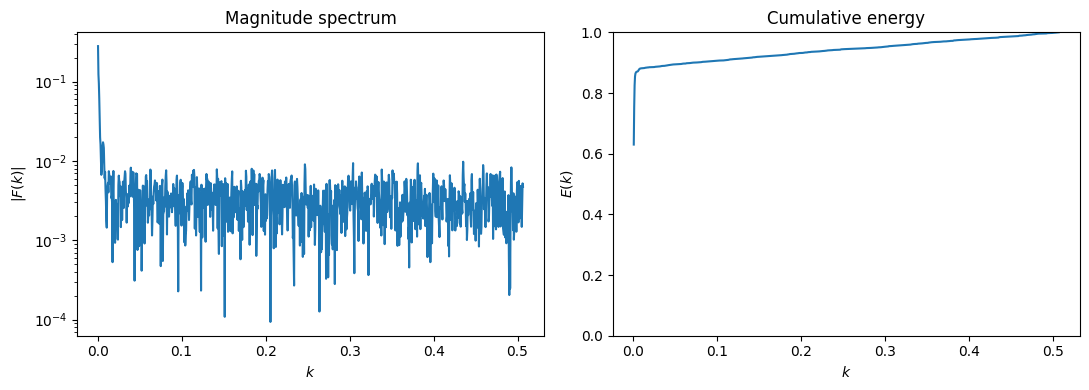

/tmp/ipykernel_3232083/477595629.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)
2025-07-20 21:00:06,611 - f_eval - INFO - Successfully merged tuned config into args.config


Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0               1454.536455            0.000000            20.826022
1                  1.246494            0.078462             0.798826
2               1138.642320            0.000000             2.570724
3                 19.909736            0.000000             1.216228
4              29505.321187            0.000000            51.047968
5                 20.990547            0.000000             1.370988
6                  6.876649            0.000000             1.133599
Relative Slopes Statistics:
   feature  count       mean         std       min           max    median  \
0        0   1864  20.826022  123.274007  0.000000   1454.536455  1.586626   
1        1     94   0.798826    0.342481  0.078462      1.246494  0.861294   
2        2   7280   2.570724   34.563070  0.000000   1138.642320  0.344002   
3        3  1

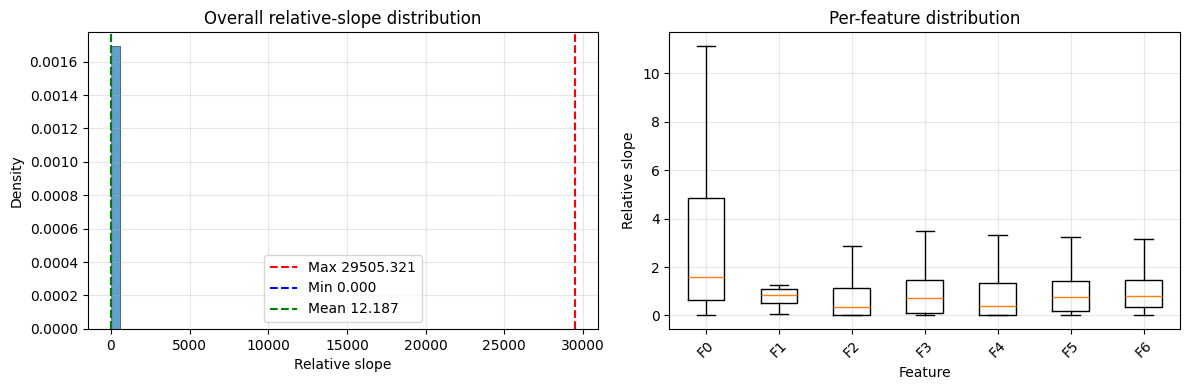

In [9]:
transform_list = [
    {
        'stretch_opt': 
            {
                'lambda_': 0.733,
                'n_bins': 64
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]
N_trans, C_trans, y_trans, trans_results_stretch_opt = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

logger = get_logger('f_eval')
args = copy.deepcopy(args)
args.save_path = f'results_model/stretch_opt/{dataset_name}-mlp-Tune/Epoch200BZ1024'
args.transform_list = transform_list
args, is_loaded = load_tuned_config(args, logger=logger)
print(f"Loaded config status: {is_loaded}")

method_stretch_opt = get_method(args.model_type)(args, is_regression)
method_stretch_opt.pre_transformed = True
train_val_data = (copy.deepcopy(N_trans), copy.deepcopy(C_trans), copy.deepcopy(y_trans))
time_cost = method_stretch_opt.fit(train_val_data, info)

# Custom

Fitting MultiResolution transform...
Fit complete.
Transforming with MultiResolution transform...
  - Transformed 'train' data from shape (760, 22) to (760, 198) (grouped by feature)
  - Transformed 'val' data from shape (190, 22) to (190, 198) (grouped by feature)


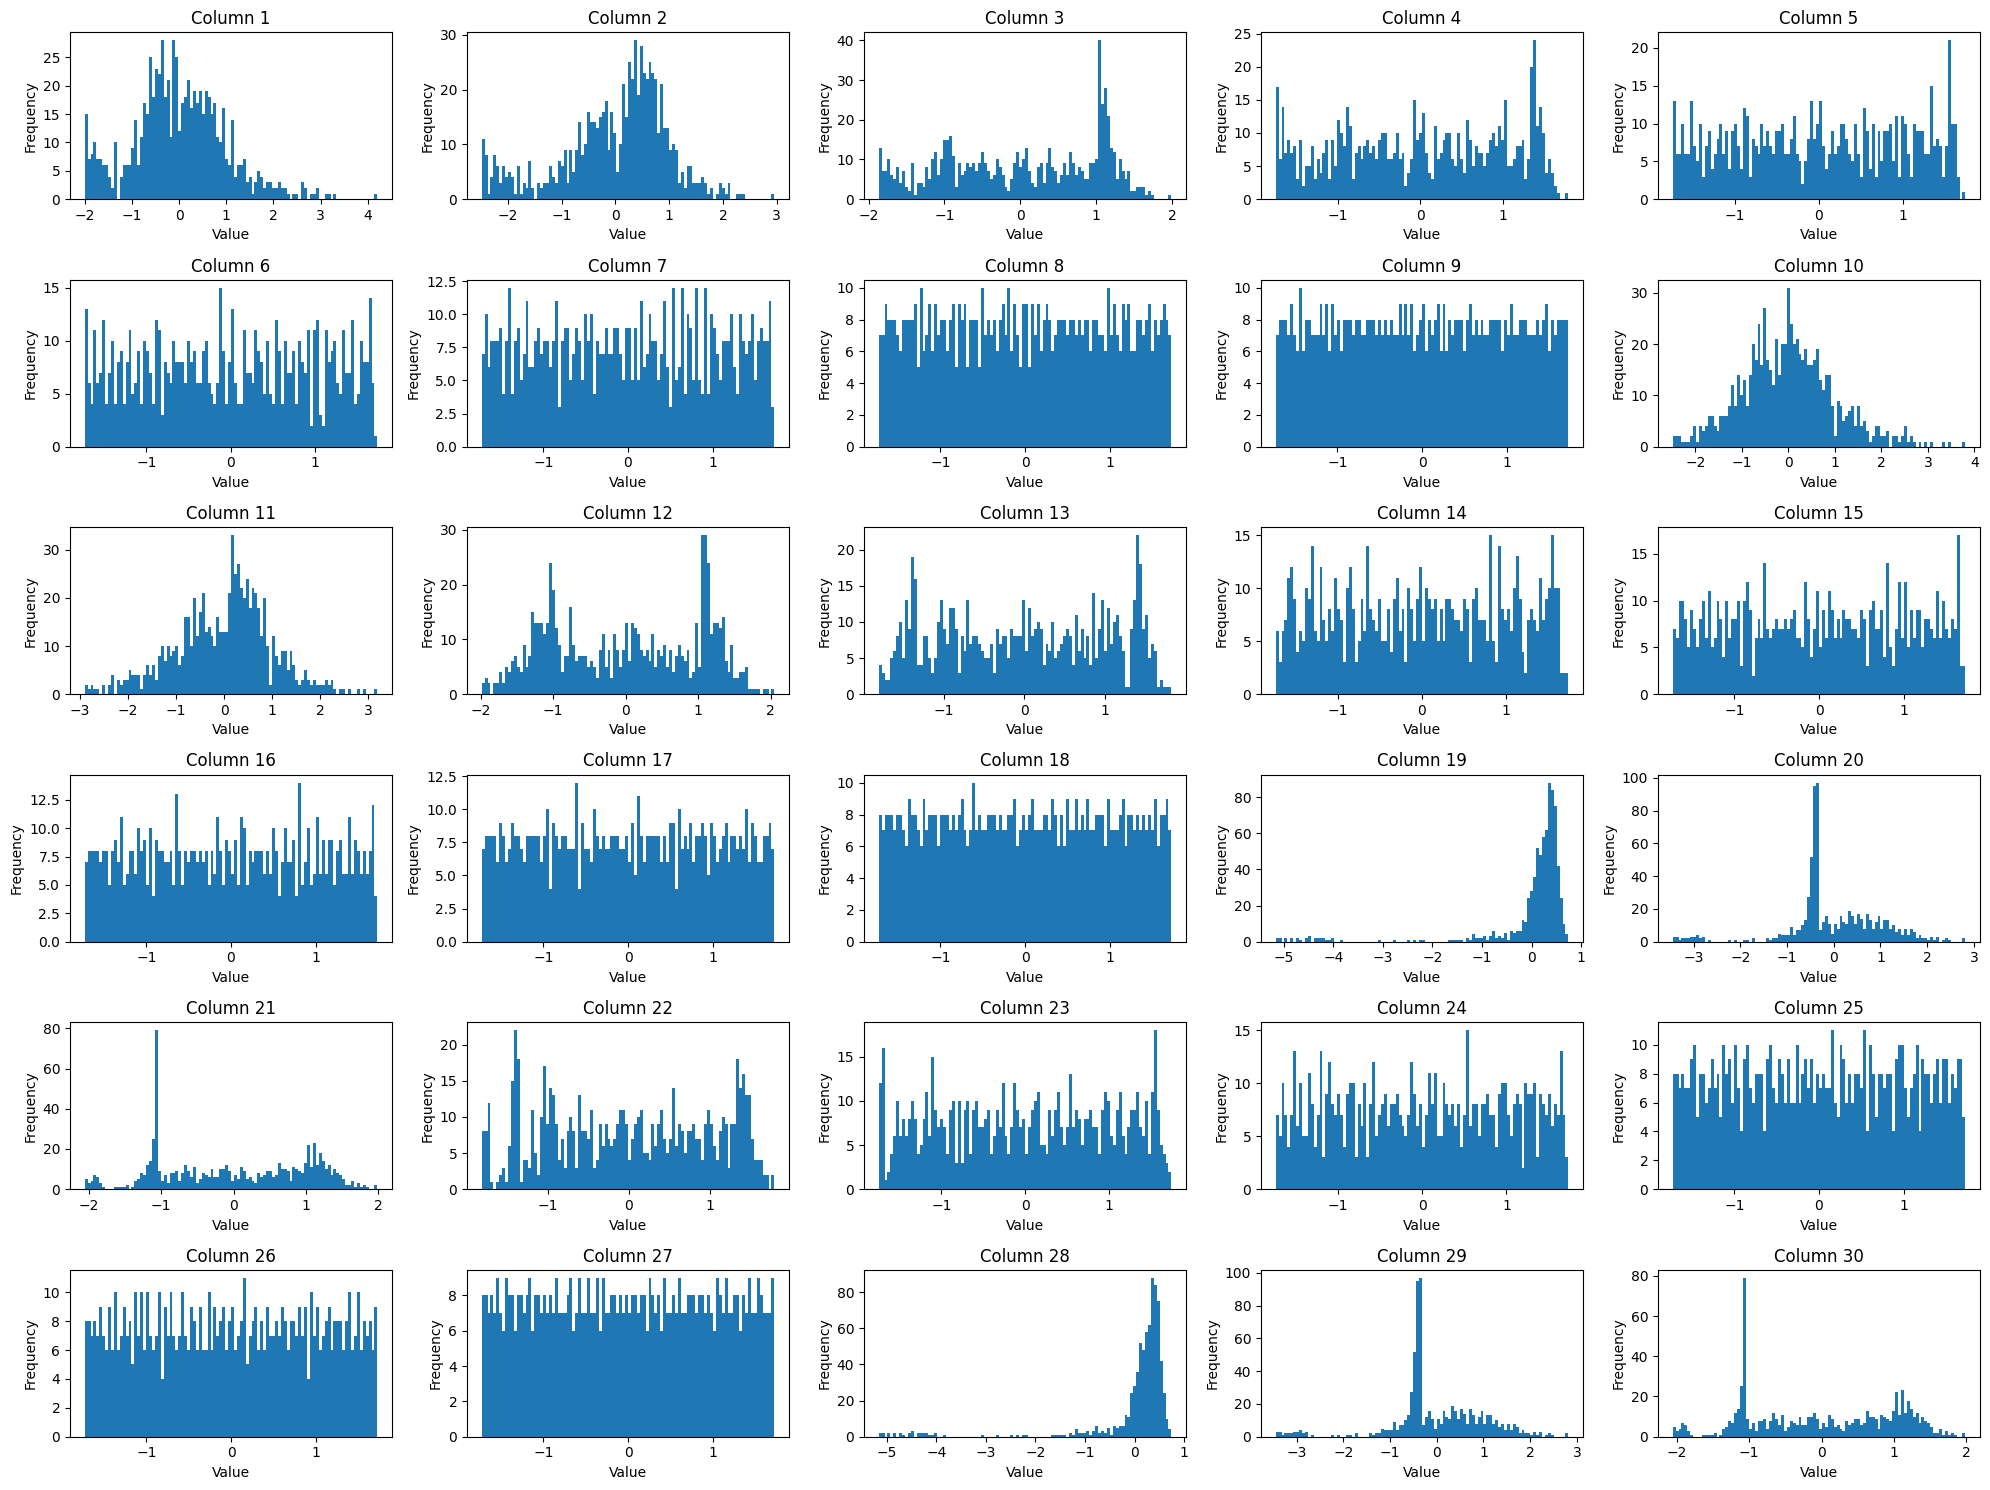

HF-energy (> 40% Nyq)  = 37.91%
Spectral-decay exponent α  ≈ -0.02



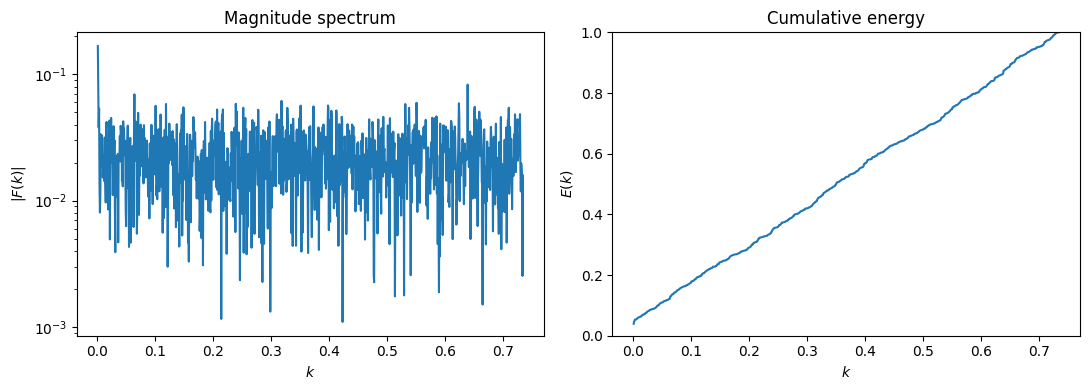

Relative Slopes Analysis:
         max_relative_slope  min_relative_slope  mean_relative_slope
feature                                                             
0               1634.057545                 0.0            11.208700
1               1020.659320                 0.0            10.363925
2               1042.312019                 0.0             9.915539
3               1699.820042                 0.0             9.094644
4                561.990451                 0.0             6.619738
5                630.775780                 0.0             6.532214
6                820.665309                 0.0             6.124689
7                752.652635                 0.0             5.704716
8                306.786872                 0.0             3.990931
9                663.152171                 0.0            10.259832
10               610.587336                 0.0            10.147536
11              1022.282228                 0.0             9.145261
12      

/tmp/ipykernel_1068293/477595629.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(feature_data, labels=labels, showfliers=False)


Relative Slopes Statistics:
     feature  count       mean         std  min           max    median  q25  \
0          0   1518  11.208700   68.309979  0.0   1634.057545  0.000000  0.0   
1          1   1518  10.363925   53.478254  0.0   1020.659320  0.000000  0.0   
2          2   1518   9.915539   62.007129  0.0   1042.312019  0.000000  0.0   
3          3   1518   9.094644   70.759501  0.0   1699.820042  0.000000  0.0   
4          4   1518   6.619738   34.677242  0.0    561.990451  0.000000  0.0   
5          5   1518   6.532214   36.628030  0.0    630.775780  0.000000  0.0   
6          6   1518   6.124689   37.294950  0.0    820.665309  0.000000  0.0   
7          7   1518   5.704716   34.194824  0.0    752.652635  0.000000  0.0   
8          8   1518   3.990931   17.925081  0.0    306.786872  0.000000  0.0   
9          9   1518  10.259832   47.944791  0.0    663.152171  0.000000  0.0   
10        10   1518  10.147536   48.309162  0.0    610.587336  0.000000  0.0   
11        11

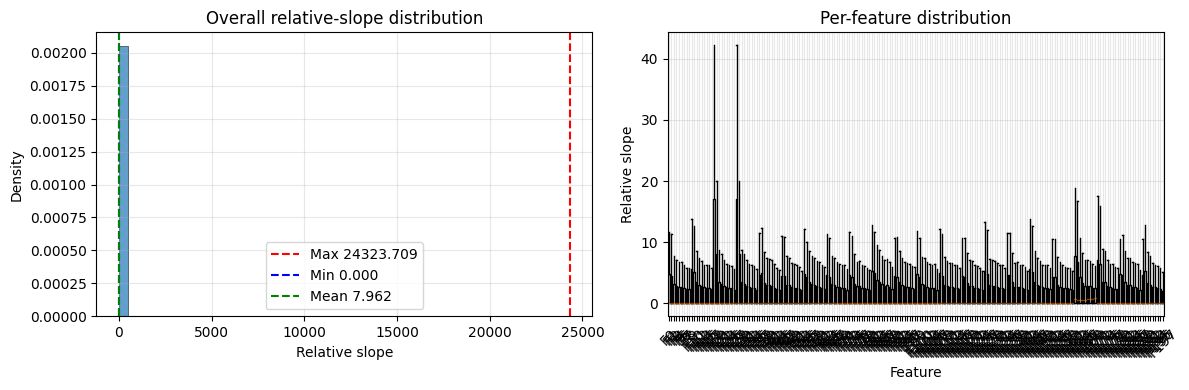

In [8]:
transform_list = [
    {
        'multi_uniple':
            {
                'n_bins': 256
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    }
]
import os
N_trans, C_trans, y_trans, trans_results_stretch_opt = transform_analysis(transform_list, N_data, C_data, y_data, is_regression)

# logger = get_logger('f_eval')
# args = copy.deepcopy(args)
# args.save_path = f'results_model/default_path/{dataset_name}-mlp-Tune/Epoch200BZ1024'
# args.transform_list = transform_list
# args, is_loaded = load_tuned_config(args, logger=logger)
# print(f"Loaded config status: {is_loaded}")

# method_custom = get_method(args.model_type)(args, is_regression)
# method_custom.pre_transformed = True
# train_val_data = (copy.deepcopy(N_trans), copy.deepcopy(C_trans), copy.deepcopy(y_trans))
# time_cost = method_custom.fit(train_val_data, info)

# Per feature slope analysis

## No Tranform

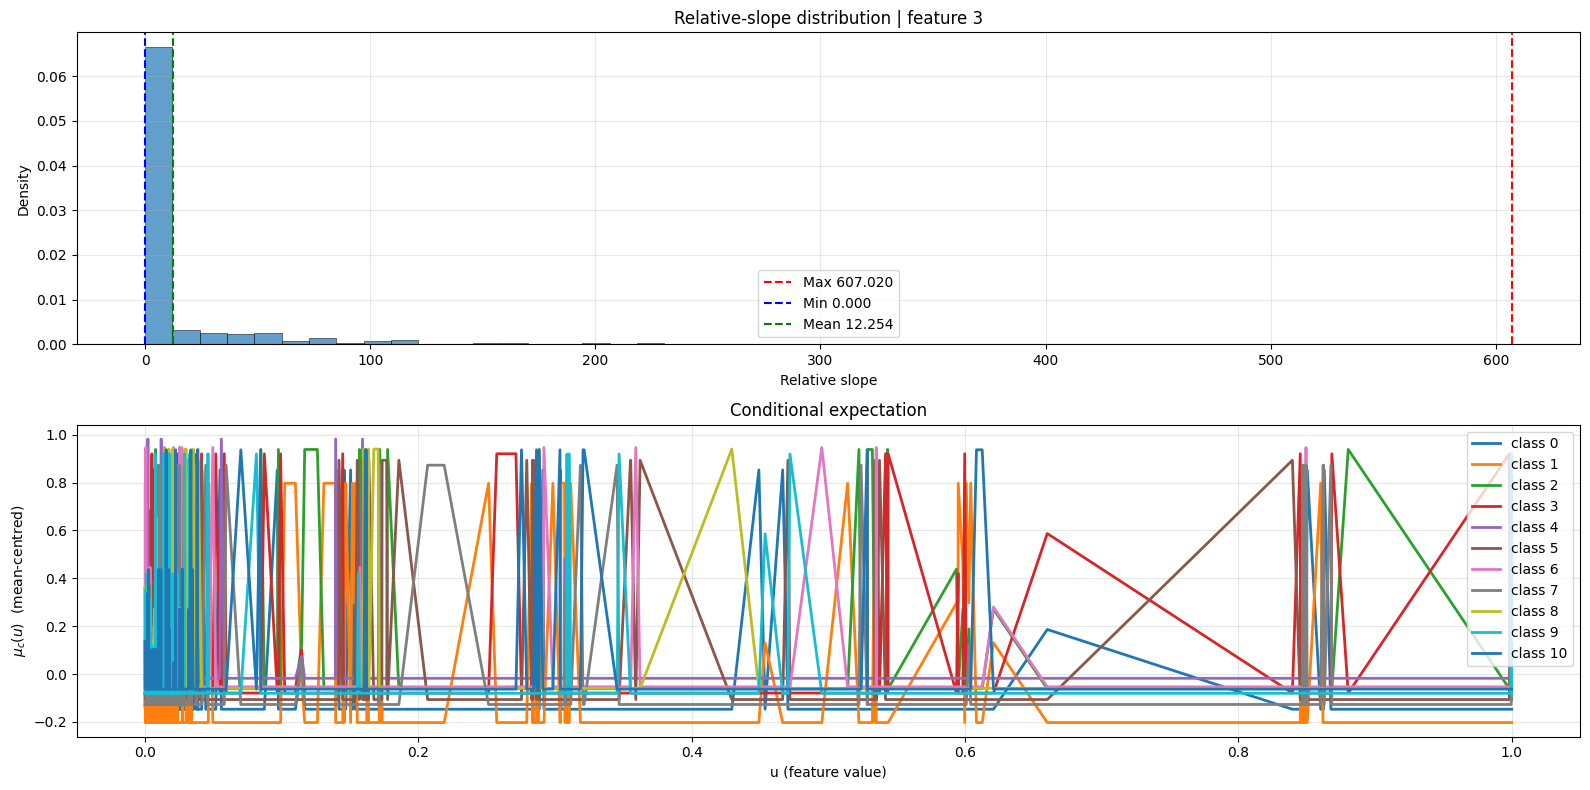

In [10]:
plot_relative_slope_distribution(ori_no_transform, feature_idx=3, figsize=(16, 8))
plt.show()

## PLE-Uni

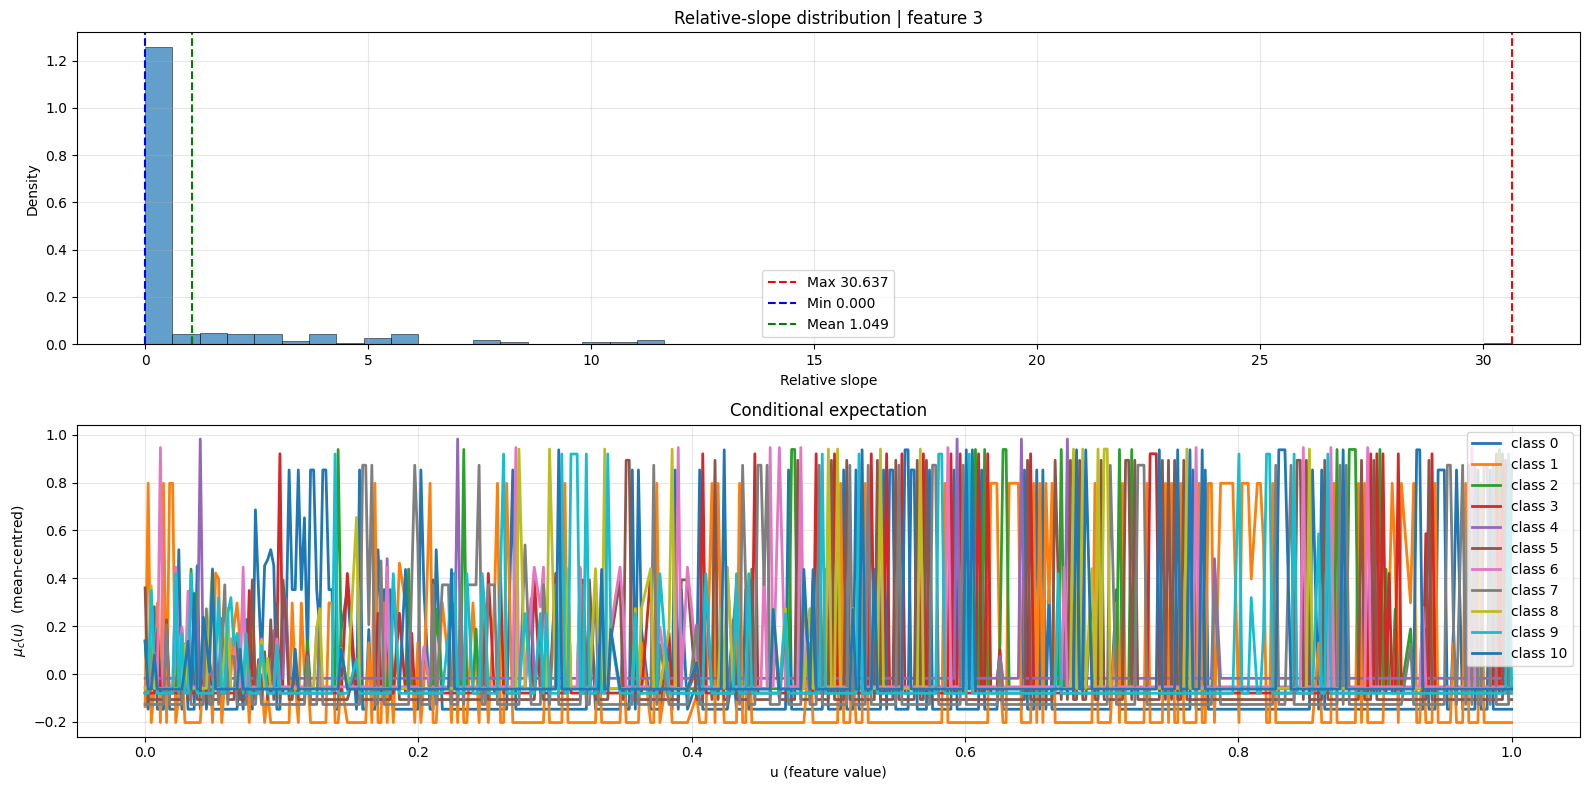

In [12]:
plot_relative_slope_distribution(trans_results_cdf, feature_idx=3, figsize=(16, 8))
plt.show()

## Stretch Opt

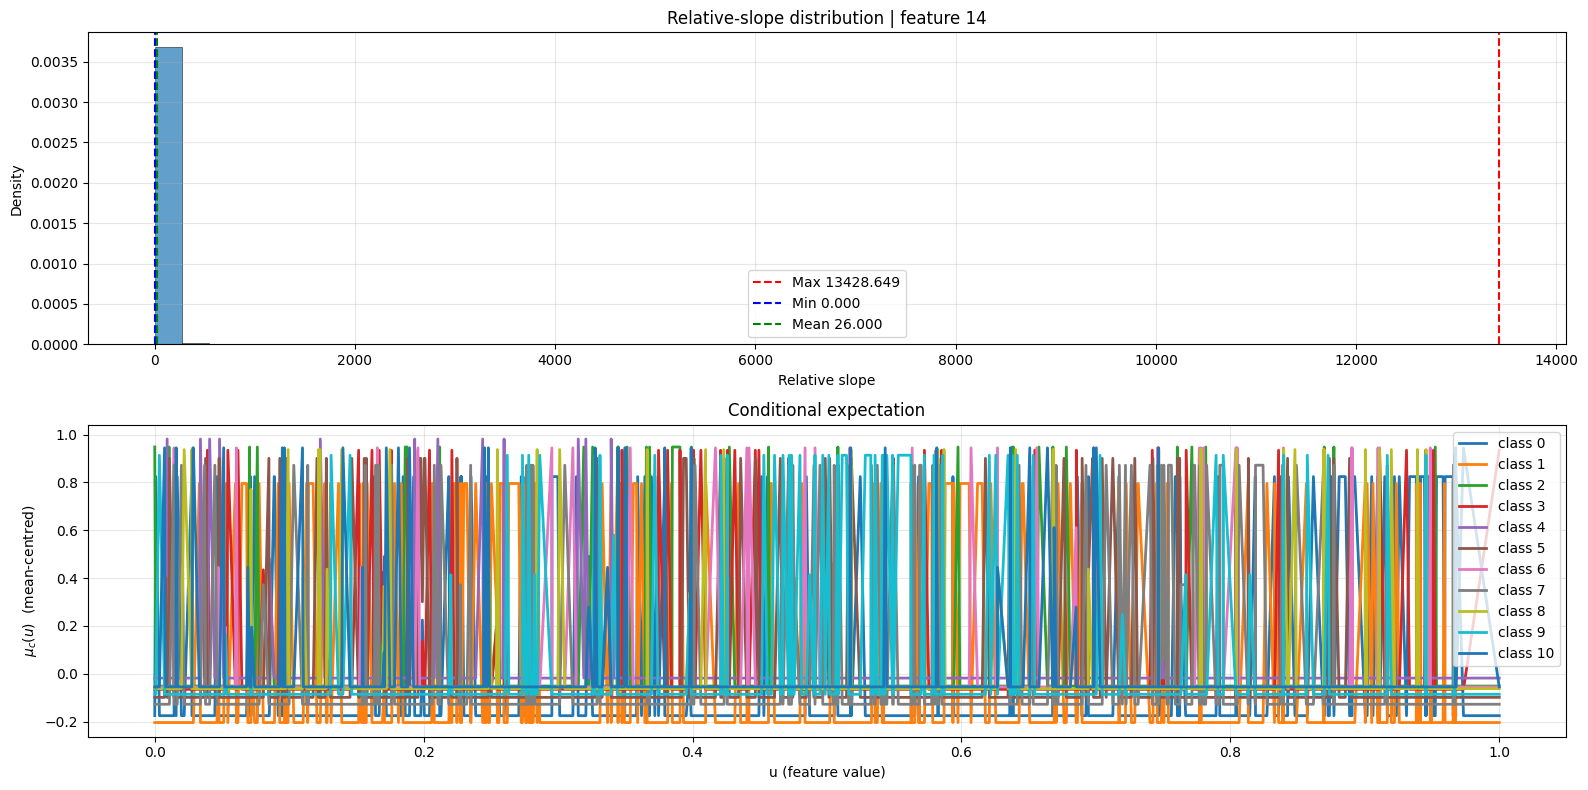

In [17]:
plot_relative_slope_distribution(trans_results_stretch_opt, feature_idx=14, figsize=(16, 8))
plt.show()

# Feature Plot

## No Transform

  0%|          | 0/29 [00:00<?, ?it/s]

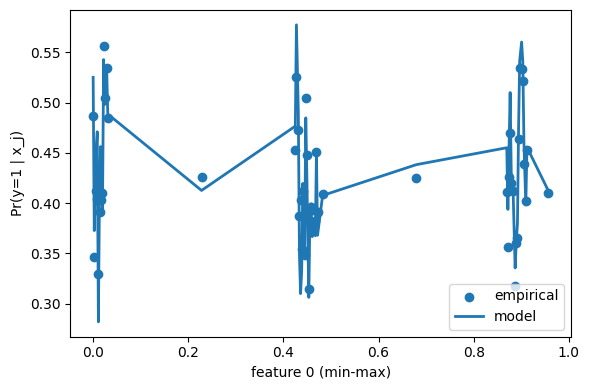

In [15]:
plot_feature_response(method_no_transform, feature_idx=0, n_bins=50, class_id=None)

## PLE-Uni

 38%|███▊      | 11/29 [00:00<00:00, 106.20it/s]

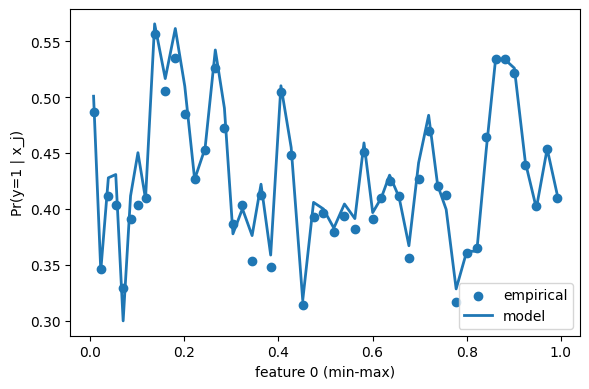

In [16]:
plot_feature_response(method_cdf, feature_idx=0, n_bins=50, class_id=None)

## Stretch Opt

  0%|          | 0/29 [00:00<?, ?it/s]

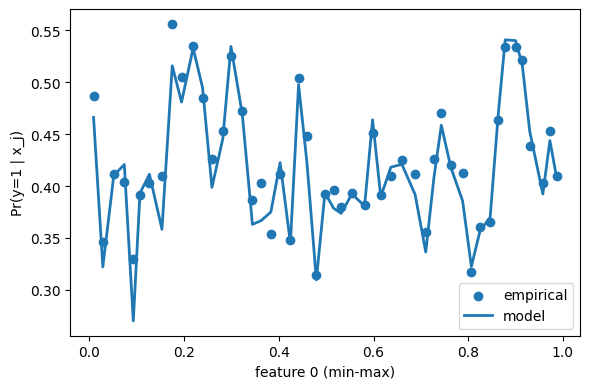

In [17]:
plot_feature_response(method_stretch_opt, feature_idx=0, n_bins=50, class_id=None)

## Custom

  0%|          | 0/29 [00:00<?, ?it/s]

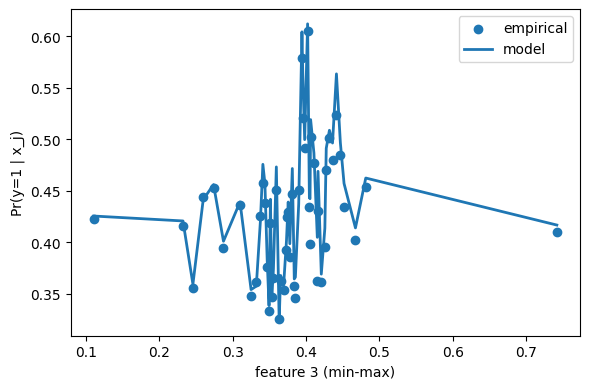

In [21]:
plot_feature_response(method_custom, feature_idx=3, n_bins=50, class_id=None)
